# Script 1 Independent EEG QC Review Notebook

## Default example: `IC01_BG_EEG.csv`

`IC01_BG` is used because it contains peak-to-peak failures, maximum-step-only failures, failures of both rules, clustered artifacts, and a relatively low retention rate. It is therefore a useful standalone inspection case.

This notebook is **inspection only**. It does not contain any previous manual decisions and does not change the automatic keep/reject result.

It will:

1. load one recording;
2. remove the first 15 seconds;
3. apply the fixed 1–30 Hz filter;
4. divide the recording into 4-second epochs;
5. apply peak-to-peak and maximum-step QC;
6. generate a reason-coloured QC overview;
7. create a review queue containing all automatically rejected epochs;
8. inspect any selected epoch with its neighbours and raw signal;
9. export a blank decision CSV for use by a separate processing notebook.


In [1]:
# =========================================================
# 1. IMPORTS AND USER SETTINGS
# =========================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import display


plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False


# Change only this path.
DATA_DIR = Path(
    r"C:\Users\Harvey McWalter\Desktop\EEG_Data"
)

# Default inspection case.
REVIEW_FILE = (
    DATA_DIR
    / "IC01_BG_EEG.csv"
)

OUTPUT_DIR = (
    DATA_DIR
    / "Independent_EEG_QC_Review"
)

PLOT_DIR = (
    OUTPUT_DIR
    / "review_plots"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FS = 500
RIGHT_EEG_COL = "CH1"
LEFT_EEG_COL = "CH2"

SCENE_NAMES = {
    "BG": "Blue-Green",
    "G": "Green",
    "GR": "Grey",
}

START_TRIM_SECONDS = 15.0
END_TRIM_SECONDS = 0.0

EEG_BAND = (1.0, 30.0)
FILTER_ORDER = 4
EPOCH_SECONDS = 4.0
NUMBER_OF_MADS = 6.0

# Current assumption: CSV values are volts.
V_TO_UV = 1_000_000


print("Review file:", REVIEW_FILE)
print("Output folder:", OUTPUT_DIR)


Review file: C:\Users\Harvey McWalter\Desktop\EEG_Data\IC01_BG_EEG.csv
Output folder: C:\Users\Harvey McWalter\Desktop\EEG_Data\Independent_EEG_QC_Review


## Common processing functions

These reproduce the automatic QC logic used by the pilot batch pipeline. No manual rule is included.


In [2]:
# =========================================================
# 2. COMMON FUNCTIONS
# =========================================================

def parse_filename(file_path):
    pattern = re.compile(
        r"^(?P<participant>[A-Za-z]+\d+)_"
        r"(?P<scene>BG|GR|G)_EEG$",
        flags=re.IGNORECASE,
    )

    match = pattern.fullmatch(
        file_path.stem
    )

    if match is None:
        raise ValueError(
            f"Unexpected filename: {file_path.name}"
        )

    participant = (
        match.group("participant")
        .upper()
    )

    scene_code = (
        match.group("scene")
        .upper()
    )

    return {
        "participant": participant,
        "scene_code": scene_code,
        "scene_name": SCENE_NAMES[
            scene_code
        ],
    }


def load_recording(file_path):
    if not file_path.exists():
        raise FileNotFoundError(
            f"File not found: {file_path}"
        )

    df = pd.read_csv(
        file_path,
        low_memory=False,
    )

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
    )

    required_columns = [
        RIGHT_EEG_COL,
        LEFT_EEG_COL,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing columns: {missing_columns}"
        )

    for column in required_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    if df[required_columns].isna().any().any():
        raise ValueError(
            "EEG columns contain NaN or "
            "non-numeric values."
        )

    return df


def bandpass_filter(
    x,
    fs,
    lowcut,
    highcut,
    order=4,
):
    x = np.asarray(
        x,
        dtype=float,
    )

    sos = signal.butter(
        N=order,
        Wn=[
            lowcut,
            highcut,
        ],
        btype="bandpass",
        fs=fs,
        output="sos",
    )

    return signal.sosfiltfilt(
        sos,
        x,
    )


def create_epochs(
    x,
    fs,
    epoch_seconds,
):
    x = np.asarray(
        x,
        dtype=float,
    )

    samples_per_epoch = int(
        round(
            fs * epoch_seconds
        )
    )

    number_of_epochs = (
        len(x)
        // samples_per_epoch
    )

    if number_of_epochs < 1:
        raise ValueError(
            "Recording is shorter than "
            "one complete epoch."
        )

    usable_length = (
        number_of_epochs
        * samples_per_epoch
    )

    return x[
        :usable_length
    ].reshape(
        number_of_epochs,
        samples_per_epoch,
    )


def robust_upper_threshold(
    values,
    number_of_mads=6.0,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    median_value = np.median(
        values
    )

    mad = np.median(
        np.abs(
            values - median_value
        )
    )

    robust_sd = (
        1.4826 * mad
    )

    if robust_sd == 0:
        return (
            median_value * 3
            if median_value > 0
            else np.inf
        )

    threshold = (
        median_value
        + number_of_mads
        * robust_sd
    )

    return max(
        threshold,
        median_value * 3,
    )


def assess_epoch_quality(
    epochs,
    epoch_seconds,
    number_of_mads=6.0,
):
    epochs = np.asarray(
        epochs,
        dtype=float,
    )

    peak_to_peak = np.ptp(
        epochs,
        axis=1,
    )

    maximum_step = np.max(
        np.abs(
            np.diff(
                epochs,
                axis=1,
            )
        ),
        axis=1,
    )

    ptp_threshold = (
        robust_upper_threshold(
            peak_to_peak,
            number_of_mads,
        )
    )

    step_threshold = (
        robust_upper_threshold(
            maximum_step,
            number_of_mads,
        )
    )

    failed_ptp = (
        peak_to_peak
        > ptp_threshold
    )

    failed_step = (
        maximum_step
        > step_threshold
    )

    auto_reason = np.select(
        [
            failed_ptp
            & failed_step,

            failed_ptp,

            failed_step,
        ],
        [
            "both",
            "ptp_only",
            "step_only",
        ],
        default="kept",
    )

    auto_keep = (
        ~(failed_ptp | failed_step)
    )

    epoch_numbers = np.arange(
        len(epochs)
    )

    quality_table = pd.DataFrame({
        "epoch":
            epoch_numbers,

        "start_time_s":
            epoch_numbers
            * epoch_seconds,

        "end_time_s":
            (
                epoch_numbers + 1
            )
            * epoch_seconds,

        "peak_to_peak_uv":
            peak_to_peak,

        "maximum_step_uv":
            maximum_step,

        "failed_ptp":
            failed_ptp,

        "failed_step":
            failed_step,

        "auto_reason":
            auto_reason,

        "auto_keep":
            auto_keep,
    })

    return {
        "quality_table":
            quality_table,

        "ptp_threshold_uv":
            ptp_threshold,

        "step_threshold_uv":
            step_threshold,
    }


def neighbour_median(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    previous_values = np.concatenate(
        [
            [np.nan],
            values[:-1],
        ]
    )

    next_values = np.concatenate(
        [
            values[1:],
            [np.nan],
        ]
    )

    return np.nanmedian(
        np.vstack(
            [
                previous_values,
                next_values,
            ]
        ),
        axis=0,
    )



## Run the fixed automatic QC

This cell creates the automatic right-ear and left-ear QC tables. No human decision is applied.


In [3]:
# =========================================================
# 3. LOAD, FILTER, EPOCH AND AUTOMATIC QC
# =========================================================

metadata = parse_filename(
    REVIEW_FILE
)

df = load_recording(
    REVIEW_FILE
)

right_raw_v = (
    df[RIGHT_EEG_COL]
    .to_numpy(dtype=float)
)

left_raw_v = (
    df[LEFT_EEG_COL]
    .to_numpy(dtype=float)
)


start_sample = int(
    round(
        START_TRIM_SECONDS
        * FS
    )
)

if END_TRIM_SECONDS > 0:
    end_sample = (
        len(df)
        - int(
            round(
                END_TRIM_SECONDS
                * FS
            )
        )
    )
else:
    end_sample = len(df)


right_analysis_raw_v = (
    right_raw_v[
        start_sample:end_sample
    ]
)

left_analysis_raw_v = (
    left_raw_v[
        start_sample:end_sample
    ]
)


right_filtered_uv = (
    bandpass_filter(
        right_analysis_raw_v,
        FS,
        EEG_BAND[0],
        EEG_BAND[1],
        FILTER_ORDER,
    )
    * V_TO_UV
)

left_filtered_uv = (
    bandpass_filter(
        left_analysis_raw_v,
        FS,
        EEG_BAND[0],
        EEG_BAND[1],
        FILTER_ORDER,
    )
    * V_TO_UV
)


right_epochs = create_epochs(
    right_filtered_uv,
    FS,
    EPOCH_SECONDS,
)

left_epochs = create_epochs(
    left_filtered_uv,
    FS,
    EPOCH_SECONDS,
)


right_quality = (
    assess_epoch_quality(
        right_epochs,
        EPOCH_SECONDS,
        NUMBER_OF_MADS,
    )
)

left_quality = (
    assess_epoch_quality(
        left_epochs,
        EPOCH_SECONDS,
        NUMBER_OF_MADS,
    )
)


right_qc_table = (
    right_quality[
        "quality_table"
    ]
    .copy()
)

right_qc_table[
    "channel"
] = "right"


left_qc_table = (
    left_quality[
        "quality_table"
    ]
    .copy()
)

left_qc_table[
    "channel"
] = "left"


print(
    f"{metadata['participant']} - "
    f"{metadata['scene_name']}"
)

print(
    f"Original duration: "
    f"{len(df) / FS:.2f} s"
)

print(
    f"Duration after trimming: "
    f"{len(right_analysis_raw_v) / FS:.2f} s"
)

print(
    f"Number of complete epochs: "
    f"{len(right_epochs)}"
)

print(
    f"Right automatically kept: "
    f"{right_qc_table['auto_keep'].sum()}"
    f"/{len(right_qc_table)}"
)

print(
    f"Left automatically kept: "
    f"{left_qc_table['auto_keep'].sum()}"
    f"/{len(left_qc_table)}"
)


IC01 - Blue-Green
Original duration: 291.36 s
Duration after trimming: 276.36 s
Number of complete epochs: 69
Right automatically kept: 52/69
Left automatically kept: 61/69


## Reason-coloured QC overview

The four panels show peak-to-peak and maximum-step separately. This explains why an epoch below the peak-to-peak threshold can still be rejected by the maximum-step rule.


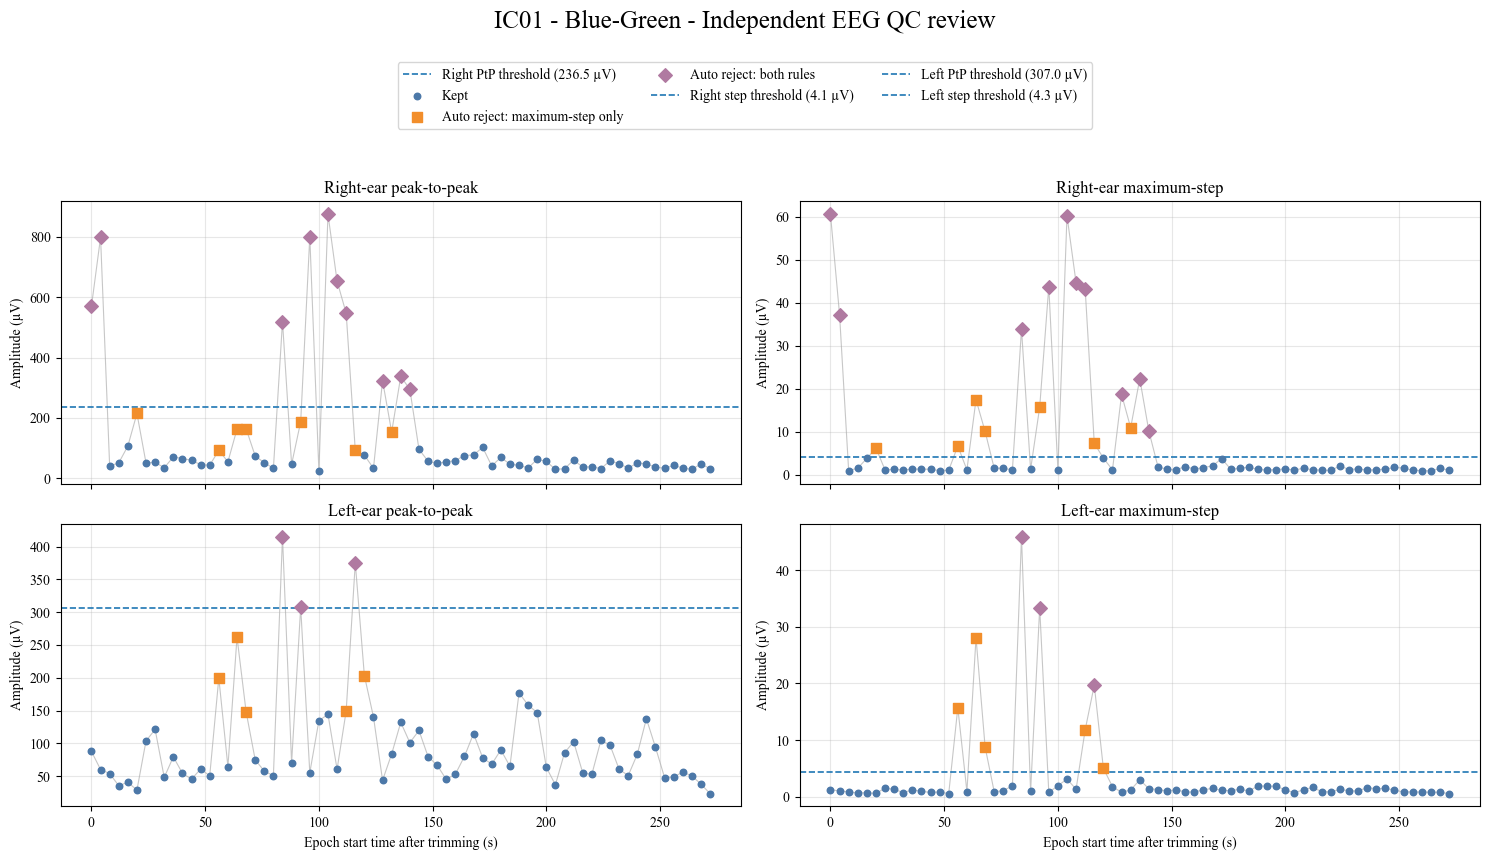

Saved: C:\Users\Harvey McWalter\Desktop\EEG_Data\Independent_EEG_QC_Review\IC01_BG_EEG_independent_QC.png


In [4]:
# =========================================================
# 4. REASON-COLOURED QC OVERVIEW
# =========================================================

def plot_reason_coloured_qc(
    metadata,
    right_table,
    left_table,
    right_quality,
    left_quality,
):
    reason_styles = {
        "kept": {
            "color": "#4c78a8",
            "marker": "o",
            "label": "Kept",
            "size": 22,
        },

        "ptp_only": {
            "color": "#e15759",
            "marker": "x",
            "label":
                "Auto reject: "
                "peak-to-peak only",
            "size": 65,
        },

        "step_only": {
            "color": "#f28e2b",
            "marker": "s",
            "label":
                "Auto reject: "
                "maximum-step only",
            "size": 45,
        },

        "both": {
            "color": "#b07aa1",
            "marker": "D",
            "label":
                "Auto reject: both rules",
            "size": 48,
        },
    }

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 9),
        sharex=True,
    )

    panel_items = [
        (
            axes[0, 0],
            right_table,
            "peak_to_peak_uv",
            right_quality[
                "ptp_threshold_uv"
            ],
            "Right-ear peak-to-peak",
            "Right PtP threshold",
        ),
    
        (
            axes[0, 1],
            right_table,
            "maximum_step_uv",
            right_quality[
                "step_threshold_uv"
            ],
            "Right-ear maximum-step",
            "Right step threshold",
        ),
    
        (
            axes[1, 0],
            left_table,
            "peak_to_peak_uv",
            left_quality[
               "ptp_threshold_uv"
            ],
            "Left-ear peak-to-peak",
            "Left PtP threshold",
        ),

        (
            axes[1, 1],
            left_table,
            "maximum_step_uv",
            left_quality[
               "step_threshold_uv"
            ],
            "Left-ear maximum-step",
            "Left step threshold",
        ),
    ]

    for (
        ax,
        table,
        metric_column,
        threshold,
        title,
        threshold_label,
    ) in panel_items:

        ax.plot(
            table[
                "start_time_s"
            ],
            table[
                metric_column
            ],
            color="#c7c7c7",
            linewidth=0.8,
            zorder=1,
        )

        ax.axhline(
            threshold,
            color="#1f77b4",
            linestyle="--",
            linewidth=1.2,
            label=(
                f"{threshold_label} "
                f"({threshold:.1f} µV)"
            ),
            zorder=2,
        )

        for (
            reason,
            style,
        ) in reason_styles.items():

            subset = table.loc[
                table[
                    "auto_reason"
                ] == reason
            ]

            if subset.empty:
                continue

            ax.scatter(
                subset[
                    "start_time_s"
                ],
                subset[
                    metric_column
                ],
                c=style["color"],
                marker=style["marker"],
                s=style["size"],
                label=style["label"],
                zorder=3,
            )

        ax.set_title(
            title
        )

        ax.set_ylabel(
            "Amplitude (µV)"
        )

        ax.grid(
            alpha=0.3
        )

    axes[1, 0].set_xlabel(
        "Epoch start time "
        "after trimming (s)"
    )

    axes[1, 1].set_xlabel(
        "Epoch start time "
        "after trimming (s)"
    )


    handles = []
    labels = []

    for ax in axes.flat:
        current_handles, current_labels = (
            ax.get_legend_handles_labels()
        )

        for handle, label in zip(
            current_handles,
            current_labels,
        ):
            if label not in labels:
                handles.append(handle)
                labels.append(label)


    fig.suptitle(
        f"{metadata['participant']} - "
        f"{metadata['scene_name']} - "
        f"Independent EEG QC review",
        fontsize=18,
        y=0.98,
    )

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),
        ncol=3,
        frameon=True,
        fontsize=10,
    )

    plt.tight_layout(
        rect=[
            0,
            0.03,
            1,
            0.85,
        ]
    )

    output_path = (
        OUTPUT_DIR
        / f"{REVIEW_FILE.stem}_"
          f"independent_QC.png"
    )

    plt.savefig(
        output_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )


plot_reason_coloured_qc(
    metadata,
    right_qc_table,
    left_qc_table,
    right_quality,
    left_quality,
)


## Build the independent review queue

Every automatically rejected epoch is listed with filtered metrics, raw-signal metrics, and comparisons with neighbouring epochs. The decision columns remain blank.


In [5]:
# =========================================================
# 5. BUILD AND SAVE THE REVIEW QUEUE
# =========================================================

def add_raw_metrics(
    qc_table,
    raw_signal_v,
):
    output_table = (
        qc_table.copy()
    )

    raw_epochs_uv = create_epochs(
        raw_signal_v
        * V_TO_UV,
        FS,
        EPOCH_SECONDS,
    )

    raw_peak_to_peak = np.ptp(
        raw_epochs_uv,
        axis=1,
    )

    raw_maximum_step = np.max(
        np.abs(
            np.diff(
                raw_epochs_uv,
                axis=1,
            )
        ),
        axis=1,
    )

    output_table[
        "raw_peak_to_peak_uv"
    ] = raw_peak_to_peak

    output_table[
        "raw_maximum_step_uv"
    ] = raw_maximum_step

    output_table[
        "raw_ptp_neighbour_median_uv"
    ] = neighbour_median(
        raw_peak_to_peak
    )

    output_table[
        "raw_step_neighbour_median_uv"
    ] = neighbour_median(
        raw_maximum_step
    )

    output_table[
        "raw_ptp_ratio_to_neighbours"
    ] = (
        output_table[
            "raw_peak_to_peak_uv"
        ]
        /
        output_table[
            "raw_ptp_neighbour_median_uv"
        ]
    )

    output_table[
        "raw_step_ratio_to_neighbours"
    ] = (
        output_table[
            "raw_maximum_step_uv"
        ]
        /
        output_table[
            "raw_step_neighbour_median_uv"
        ]
    )

    return output_table


right_qc_with_raw = add_raw_metrics(
    right_qc_table,
    right_analysis_raw_v,
)

left_qc_with_raw = add_raw_metrics(
    left_qc_table,
    left_analysis_raw_v,
)


all_channel_qc = pd.concat(
    [
        right_qc_with_raw,
        left_qc_with_raw,
    ],
    ignore_index=True,
)


review_candidates = (
    all_channel_qc.loc[
        all_channel_qc[
            "auto_reason"
        ] != "kept"
    ]
    .copy()
    .sort_values(
        [
            "channel",
            "epoch",
        ]
    )
    .reset_index(
        drop=True
    )
)


review_candidates.insert(
    0,
    "participant",
    metadata[
        "participant"
    ],
)

review_candidates.insert(
    1,
    "scene_code",
    metadata[
        "scene_code"
    ],
)

review_candidates.insert(
    2,
    "scene_name",
    metadata[
        "scene_name"
    ],
)


review_candidates[
    "review_id"
] = (
    review_candidates[
        "participant"
    ]
    + "_"
    + review_candidates[
        "scene_code"
    ]
    + "_"
    + review_candidates[
        "channel"
    ]
    + "_epoch"
    + review_candidates[
        "epoch"
    ].astype(str)
)


review_candidates[
    "manual_decision"
] = ""

review_candidates[
    "review_note"
] = ""

review_candidates[
    "reviewer"
] = ""


review_queue_csv = (
    OUTPUT_DIR
    / f"{REVIEW_FILE.stem}_"
      f"review_queue.csv"
)

review_candidates.to_csv(
    review_queue_csv,
    index=False,
)


print(
    "Number of review candidates:",
    len(review_candidates),
)

print(
    "Saved:",
    review_queue_csv,
)

display(
    review_candidates[
        [
            "review_id",
            "auto_reason",
            "peak_to_peak_uv",
            "maximum_step_uv",
            "raw_peak_to_peak_uv",
            "raw_maximum_step_uv",
            "raw_step_ratio_to_neighbours",
            "manual_decision",
        ]
    ].round(3)
)


Number of review candidates: 25
Saved: C:\Users\Harvey McWalter\Desktop\EEG_Data\Independent_EEG_QC_Review\IC01_BG_EEG_review_queue.csv


,review_id,auto_reason,peak_to_peak_uv,maximum_step_uv,raw_peak_to_peak_uv,raw_maximum_step_uv,raw_step_ratio_to_neighbours,manual_decision
0,IC01_BG_left_epoch14,step_only,199.663,15.707,1092.291,133.562,36.145,
1,IC01_BG_left_epoch16,step_only,261.999,28.076,1209.235,246.525,5.951,
2,IC01_BG_left_epoch17,step_only,148.082,8.764,899.959,79.131,0.623,
3,IC01_BG_left_epoch21,both,414.809,45.898,1017.451,388.384,45.188,
4,IC01_BG_left_epoch23,both,307.640,33.375,770.902,277.948,74.974,
5,IC01_BG_left_epoch28,step_only,149.423,11.797,604.654,97.323,1.091,
6,IC01_BG_left_epoch29,both,375.176,19.694,809.765,164.032,2.474,
7,IC01_BG_left_epoch30,step_only,203.426,5.000,411.272,35.286,0.418,
8,IC01_BG_right_epoch0,both,569.713,60.607,783.730,135.803,2.566,
9,IC01_BG_right_epoch1,both,797.286,37.255,1538.611,52.929,0.743,


## Inspect one candidate in detail

Change `REVIEW_CHANNEL` and `REVIEW_EPOCH`, then rerun the final function call.


Current example: left 14


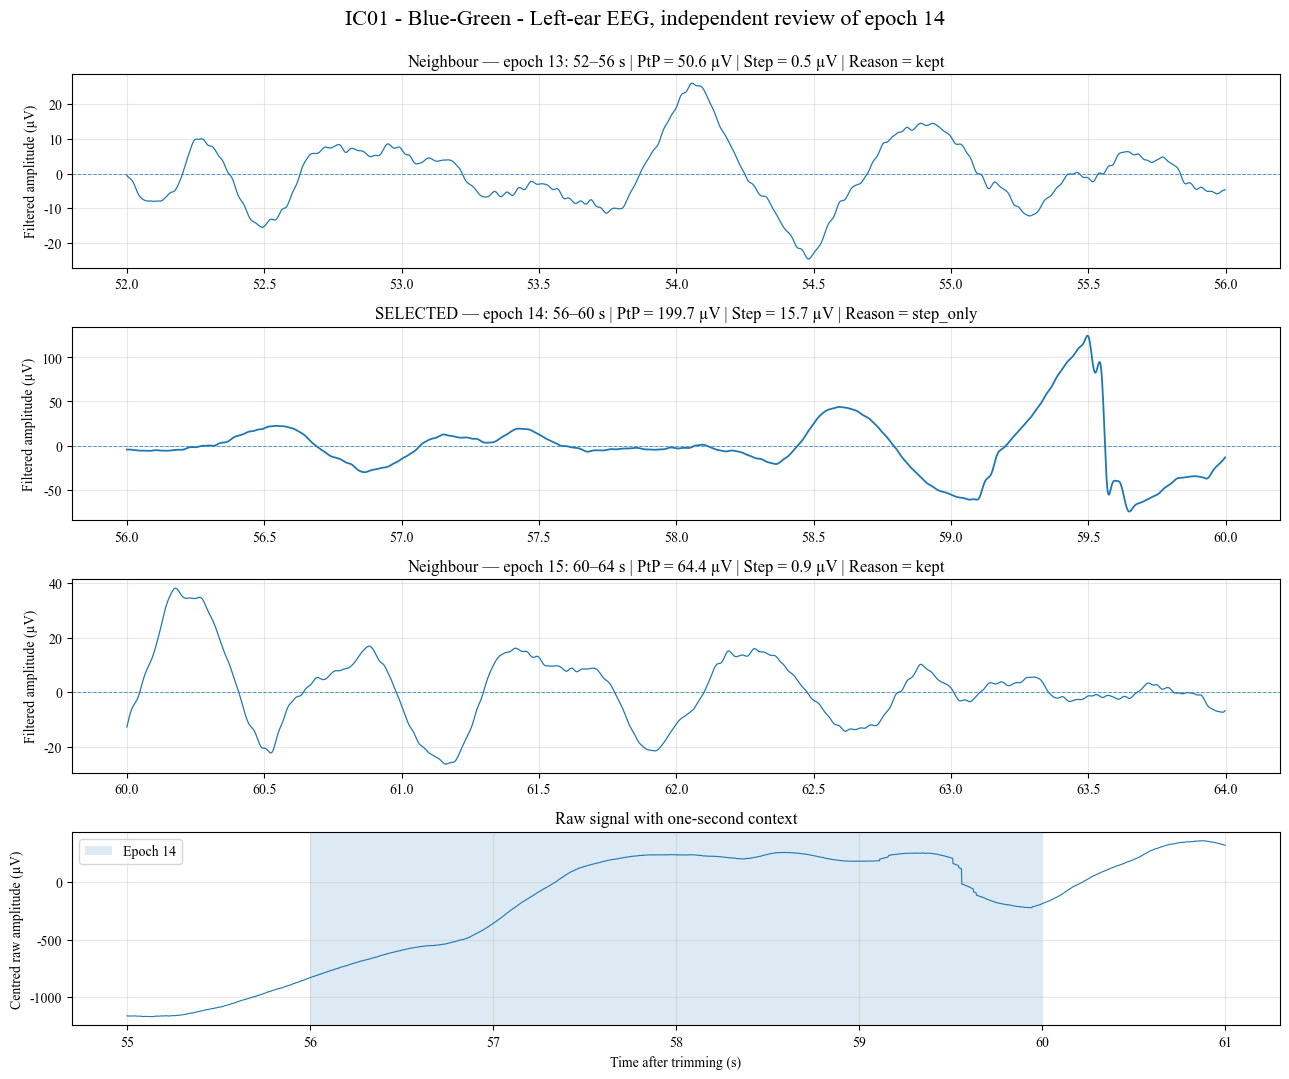

,channel,epoch,start_time_s,end_time_s,auto_reason,peak_to_peak_uv,maximum_step_uv,raw_peak_to_peak_uv,raw_maximum_step_uv,raw_step_ratio_to_neighbours
14,left,14,56.0,60.0,step_only,199.663,15.707,1092.291,133.562,36.145


Saved: C:\Users\Harvey McWalter\Desktop\EEG_Data\Independent_EEG_QC_Review\review_plots\IC01_BG_EEG_left_epoch14_review.png


In [6]:
# =========================================================
# 6. DETAILED SINGLE-EPOCH INSPECTION
# =========================================================

def inspect_epoch(
    channel,
    epoch_index,
    save_plot=True,
):
    if channel == "right":
        epochs = right_epochs
        raw_signal_v = (
            right_analysis_raw_v
        )
        channel_name = (
            "Right-ear EEG"
        )
        qc_table = (
            right_qc_with_raw
        )

    elif channel == "left":
        epochs = left_epochs
        raw_signal_v = (
            left_analysis_raw_v
        )
        channel_name = (
            "Left-ear EEG"
        )
        qc_table = (
            left_qc_with_raw
        )

    else:
        raise ValueError(
            "channel must be "
            "'right' or 'left'."
        )

    if not (
        0 <= epoch_index
        < len(epochs)
    ):
        raise IndexError(
            f"epoch_index must be "
            f"between 0 and "
            f"{len(epochs) - 1}."
        )

    selected_indices = [
        index
        for index in [
            epoch_index - 1,
            epoch_index,
            epoch_index + 1,
        ]
        if (
            0 <= index
            < len(epochs)
        )
    ]

    number_of_rows = (
        len(selected_indices) + 1
    )

    fig, axes = plt.subplots(
        number_of_rows,
        1,
        figsize=(
            13,
            2.7 * number_of_rows,
        ),
    )

    if number_of_rows == 1:
        axes = [axes]

    for (
        ax,
        current_epoch,
    ) in zip(
        axes[:-1],
        selected_indices,
    ):

        current_signal = (
            epochs[current_epoch]
        )

        start_time = (
            current_epoch
            * EPOCH_SECONDS
        )

        time_axis = (
            start_time
            + np.arange(
                current_signal.size
            ) / FS
        )

        current_row = (
            qc_table.loc[
                qc_table[
                    "epoch"
                ] == current_epoch
            ]
            .iloc[0]
        )

        if current_epoch == epoch_index:
            position_text = "SELECTED"
            linewidth = 1.3
        else:
            position_text = "Neighbour"
            linewidth = 0.9

        ax.plot(
            time_axis,
            current_signal,
            linewidth=linewidth,
        )

        ax.axhline(
            0,
            linestyle="--",
            linewidth=0.7,
            alpha=0.7,
        )

        ax.set_title(
            f"{position_text} — epoch "
            f"{current_epoch}: "
            f"{start_time:.0f}–"
            f"{start_time + EPOCH_SECONDS:.0f} s"
            f" | PtP = "
            f"{current_row['peak_to_peak_uv']:.1f} µV"
            f" | Step = "
            f"{current_row['maximum_step_uv']:.1f} µV"
            f" | Reason = "
            f"{current_row['auto_reason']}"
        )

        ax.set_ylabel(
            "Filtered amplitude (µV)"
        )

        ax.grid(
            alpha=0.3
        )


    epoch_start_s = (
        epoch_index
        * EPOCH_SECONDS
    )

    epoch_end_s = (
        epoch_start_s
        + EPOCH_SECONDS
    )

    context_start_s = max(
        0,
        epoch_start_s - 1,
    )

    context_end_s = min(
        len(raw_signal_v) / FS,
        epoch_end_s + 1,
    )

    context_start_sample = int(
        round(
            context_start_s
            * FS
        )
    )

    context_end_sample = int(
        round(
            context_end_s
            * FS
        )
    )

    raw_time_axis = (
        np.arange(
            context_start_sample,
            context_end_sample,
        ) / FS
    )

    raw_segment_uv = (
        raw_signal_v[
            context_start_sample:
            context_end_sample
        ]
        * V_TO_UV
    )

    raw_segment_uv = (
        raw_segment_uv
        - np.median(
            raw_segment_uv
        )
    )

    raw_ax = axes[-1]

    raw_ax.plot(
        raw_time_axis,
        raw_segment_uv,
        linewidth=0.8,
    )

    raw_ax.axvspan(
        epoch_start_s,
        epoch_end_s,
        alpha=0.15,
        label=f"Epoch {epoch_index}",
    )

    raw_ax.set_title(
        "Raw signal with "
        "one-second context"
    )

    raw_ax.set_xlabel(
        "Time after trimming (s)"
    )

    raw_ax.set_ylabel(
        "Centred raw amplitude (µV)"
    )

    raw_ax.grid(
        alpha=0.3
    )

    raw_ax.legend()


    fig.suptitle(
        f"{metadata['participant']} - "
        f"{metadata['scene_name']} - "
        f"{channel_name}, "
        f"independent review of "
        f"epoch {epoch_index}",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout()

    plot_path = (
        PLOT_DIR
        / f"{REVIEW_FILE.stem}_"
          f"{channel}_epoch"
          f"{epoch_index}_review.png"
    )

    if save_plot:
        plt.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()

    selected_row = (
        qc_table.loc[
            qc_table[
                "epoch"
            ] == epoch_index
        ]
        .copy()
    )

    display(
        selected_row[
            [
                "channel",
                "epoch",
                "start_time_s",
                "end_time_s",
                "auto_reason",
                "peak_to_peak_uv",
                "maximum_step_uv",
                "raw_peak_to_peak_uv",
                "raw_maximum_step_uv",
                "raw_step_ratio_to_neighbours",
            ]
        ].round(3)
    )

    if save_plot:
        print(
            "Saved:",
            plot_path,
        )


if review_candidates.empty:
    print(
        "No automatically rejected "
        "epochs were found."
    )
else:
    REVIEW_CHANNEL = (
        review_candidates.iloc[0][
            "channel"
        ]
    )

    REVIEW_EPOCH = int(
        review_candidates.iloc[0][
            "epoch"
        ]
    )

    print(
        "Current example:",
        REVIEW_CHANNEL,
        REVIEW_EPOCH,
    )

    inspect_epoch(
        REVIEW_CHANNEL,
        REVIEW_EPOCH,
    )



## Save plots for every review candidate

Set the variable below to `True` only when needed. This exports images but still applies no manual decision.


In [7]:
# =========================================================
# 7. OPTIONAL BATCH EXPORT
# =========================================================

GENERATE_ALL_REVIEW_PLOTS = False


if GENERATE_ALL_REVIEW_PLOTS:

    for _, row in (
        review_candidates.iterrows()
    ):

        inspect_epoch(
            channel=row[
                "channel"
            ],
            epoch_index=int(
                row["epoch"]
            ),
            save_plot=True,
        )

    print(
        "All candidate plots saved to:",
        PLOT_DIR,
    )

else:

    print(
        "Batch review-plot export is disabled."
    )


Batch review-plot export is disabled.


## Files produced

The notebook creates:

- a reason-coloured QC overview;
- a `review_queue.csv` listing all automatic rejections;
- optional detailed review plots.

The CSV deliberately contains blank columns:

- `manual_decision`
- `review_note`
- `reviewer`

Fill these outside this notebook with `keep` or `reject`. A separate semi-automatic processing notebook should read that CSV. This independent inspection notebook should remain unchanged and contain no hard-coded human decision.
